# Netflix Data Analysis

---
### Goal:
Analyze Netflix content to understand trends in content type,
geography, genres, and content strategy.

---
## Business Questions

This analysis aims to answer the following key questions:

• What is the distribution of Movies vs TV Shows on Netflix?  
• How has Netflix content grown over time?  
• Which genres are most common?  
• Which countries contribute the most content?  
• How recent is the content available on Netflix?  
• What are the typical characteristics of Netflix movies?  

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
sns.set_style("whitegrid")

In [111]:
df=pd.read_csv("netflix_titles.csv")

In [112]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


-------
## Data Cleaning & Preprocessing

Before performing analysis, the dataset was cleaned and preprocessed to ensure accuracy and consistency.

### Steps performed:

• Converted `date_added` column to datetime format for time-based analysis  
• Removed rows where `date_added` is missing, as they cannot be used for trend analysis  
• Handled missing values:
  - `director` and `cast` columns were left unchanged as missing values do not affect current analysis  
  - `rating` column missing values were filled with "Unknown"  
• Extracted numeric values from the `duration` column for movie analysis  
• Ensured proper data types for analysis

These steps help ensure that the analysis is reliable and free from inconsistencies.

In [113]:
# Convert date_added to datetime
df["date_added"] = pd.to_datetime(df["date_added"])

# Drop rows with missing date_added and create a clean copy
df = df.dropna(subset=["date_added"]).copy()

# Fill missing ratings
df["rating"] = df["rating"].fillna("Unknown")

## Dataset Overview

The dataset contains information about Netflix titles, including movies and TV shows.

### Key Columns:

• `type` – Indicates whether the content is a Movie or TV Show  
• `title` – Name of the content  
• `country` – Country of production  
• `release_year` – Year the content was originally released  
• `date_added` – Date the content was added to Netflix  
• `duration` – Duration of the content (minutes or seasons)  
• `listed_in` – Genre/category of the content  
• `rating` – Content rating  

### Initial Observations:

• Dataset contains both movies and TV shows  
• Some columns contain missing values (e.g., director, cast, country)  
• Duration column contains mixed formats (minutes and seasons)  

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8797 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7972 non-null   object        
 5   country       7967 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   object        
 9   duration      8794 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
 12  year_added    8797 non-null   Int64         
 13  release_lag   8797 non-null   Int64         
dtypes: Int64(2), datetime64[ns](1), int64(1), object(10)
memory usage: 1.0+ MB


In [115]:
df.describe()

,release_year
count,8797.000000
mean,2014.183472
std,8.822191
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [116]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2624
cast             825
country          830
date_added         0
release_year       0
rating             0
duration           3
listed_in          0
description        0
dtype: int64

Some columns such as director and cast contain missing values.
These will be handled where necessary.

In [117]:
# converting date_added column from object to datetime type
df["date_added"]=pd.to_datetime(df["date_added"])

In [118]:
# adding a column year_added which tell the year of the date added
df["year_added"]=df["date_added"].dt.year

In [119]:
df.shape

(8797, 13)

In [120]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


In [121]:
df["year_added"] = df["year_added"].astype("Int64")

In [122]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


In [123]:
df["type"].value_counts()

Movie      6131
TV Show    2666
Name: type, dtype: int64

---
## Analysis 1: Movies vs TV Shows

In [124]:
df["type"].value_counts()

Movie      6131
TV Show    2666
Name: type, dtype: int64

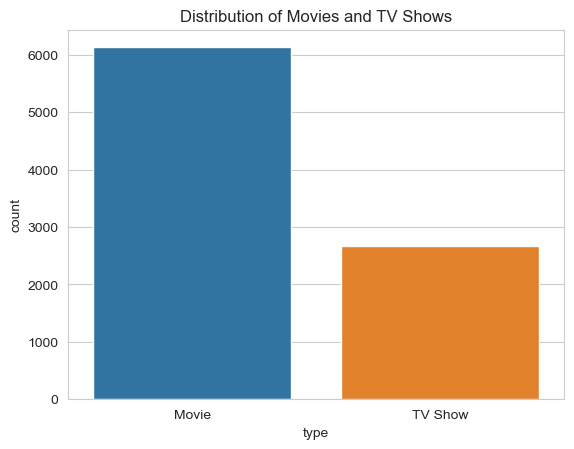

In [150]:
sns.countplot(data=df, x="type")
plt.title("Distribution of Movies and TV Shows")
plt.savefig("images/type_distribution.png")
plt.show()

### Insight

Movies dominate the Netflix catalog, indicating a stronger focus on standalone content compared to episodic formats.

---
## Analysis 2: Content Added Per Year

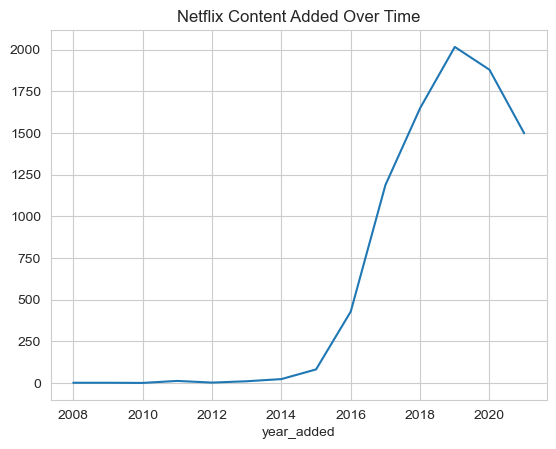

In [149]:
content_per_yr= df.groupby("year_added").size()
content_per_yr.plot()
plt.title("Netflix Content Added Over Time")
plt.savefig("images/content_growth.png")
plt.show()

### Insight

Netflix experienced rapid growth in content additions after 2016, reflecting aggressive expansion and increased investment in content production.

---
## Analysis 3: Top Countries Producing Netflix Content

In [127]:
df["country"].value_counts().head(10)

United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: country, dtype: int64

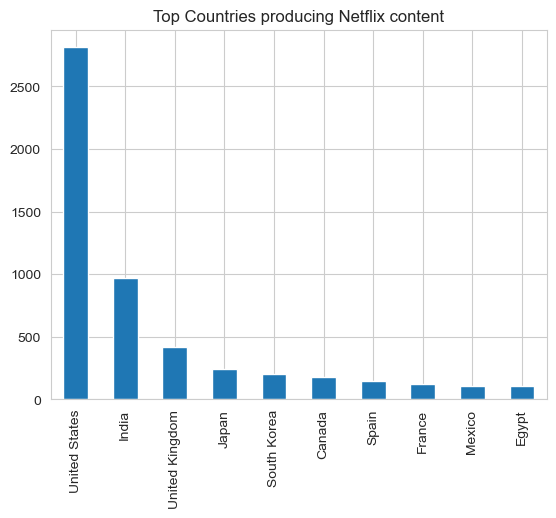

In [128]:
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top Countries producing Netflix content")
plt.show()

---
## Analysis 4: Movie Duration

In [129]:
movies=df[df["type"]=="Movie"]

In [130]:
movies["duration"].value_counts().head(10)

90 min     152
94 min     146
93 min     146
97 min     146
91 min     144
95 min     137
96 min     130
92 min     129
102 min    122
98 min     120
Name: duration, dtype: int64

### Insight

Movie durations on Netflix are heavily concentrated between 90 and 100 minutes, reflecting the standard runtime for feature-length films.

This consistency suggests that Netflix prioritizes content formats that align with traditional viewing patterns, making it easier for audiences to consume content within a typical viewing session.

---
## Analysis 5: Content Growth Analysis by Type

In [131]:
content_growth= df.groupby(["year_added", "type"]).size().unstack()

In [132]:
content_growth

type,Movie,TV Show
year_added,,
2008,1.0,1.0
2009,2.0,NaN
2010,1.0,NaN
2011,13.0,NaN
2012,3.0,NaN
2013,6.0,5.0
2014,19.0,5.0
2015,56.0,26.0
2016,253.0,176.0


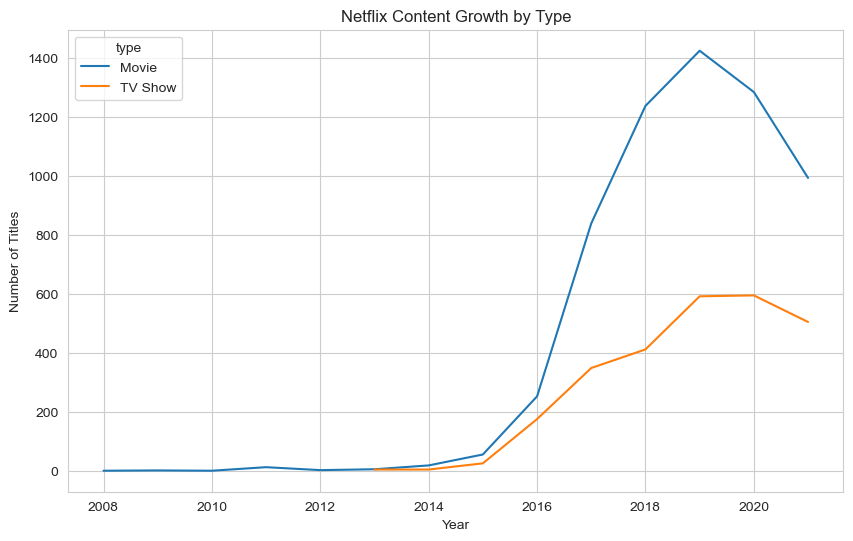

In [133]:
content_growth.plot(figsize=(10,6))
plt.title("Netflix Content Growth by Type")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

### Insight

While movies dominate overall, TV shows have shown a steady increase over time, suggesting a strategic shift towards serialized content.

---
## Analysis 6: Genre Diversity Analysis

In [134]:
genres=df["listed_in"].str.split(", ").explode()

In [135]:
genres

0                  Documentaries
1         International TV Shows
1                      TV Dramas
1                   TV Mysteries
2                 Crime TV Shows
                  ...           
8805    Children & Family Movies
8805                    Comedies
8806                      Dramas
8806        International Movies
8806            Music & Musicals
Name: listed_in, Length: 19303, dtype: object

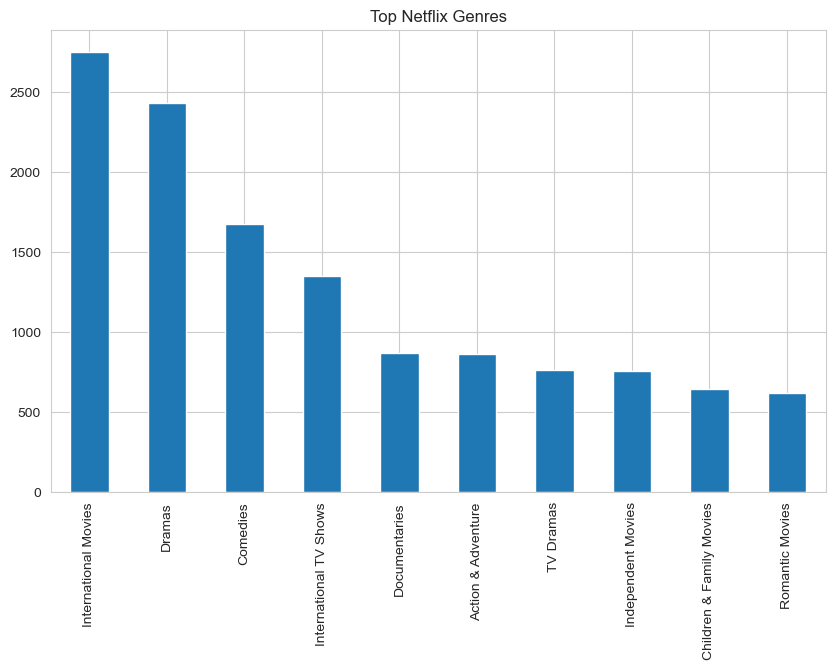

In [151]:
top_genres=genres.value_counts().head(10)
top_genres.plot(kind="bar", figsize=(10,6))
plt.title("Top Netflix Genres")
plt.savefig("images/top_genres.png")
plt.show()

### Insight

Drama and International Movies are among the most common genres, highlighting Netflix's focus on diverse and globally appealing content.

----
## Analysis 7: Country Contribution Analysis

In [137]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


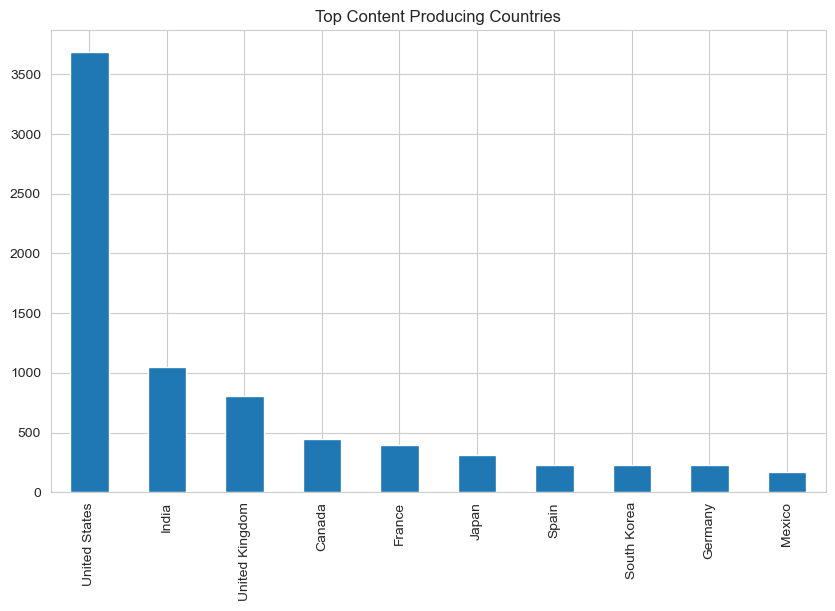

In [152]:
countries= df["country"].str.split(", ").explode()
top_countries=countries.value_counts().head(10)
top_countries.plot(kind="bar", figsize=(10,6))
plt.title("Top Content Producing Countries")
plt.savefig("images/top_countries.png")
plt.show()

### Insight

The United States contributes the majority of Netflix content, but countries like India and the United Kingdom are emerging as significant content producers.

---
## Analysis 8: Content Release Lag Analysis

In [139]:
df["release_lag"] = df["year_added"] - df["release_year"]

df["release_lag"].describe()

count      8797.0
mean     4.688417
std      8.786998
min          -3.0
25%           0.0
50%           1.0
75%           5.0
max          93.0
Name: release_lag, dtype: Float64

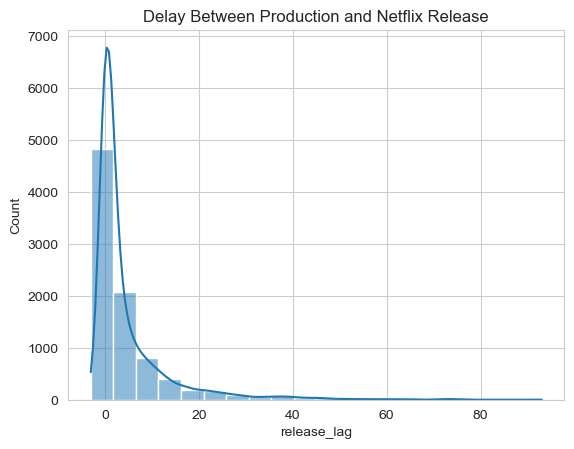

In [140]:
sns.histplot(df["release_lag"].astype(float), bins=20, kde=True)
plt.title("Delay Between Production and Netflix Release")
plt.show()

### Insight

Most content is added to Netflix within a few years of its release, indicating a focus on relatively recent content rather than older archives.

---
## Analysis 9: Movie Duration Distribution

In [141]:
movies = df[df["type"] == "Movie"].copy()

movies = movies.dropna(subset=["duration"])

movies["duration_minutes"] = movies["duration"].str.extract("(\d+)").astype(int)

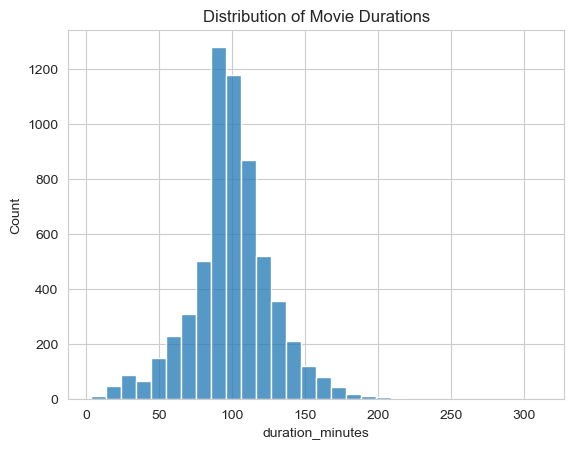

In [142]:
sns.histplot(movies["duration_minutes"], bins=30)
plt.title("Distribution of Movie Durations")
plt.show()

In [143]:
movies["duration_minutes"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

### Insight

The majority of Netflix movies fall within the standard runtime of 90 to 120 minutes, which aligns with typical industry standards.

---
## Analysis 10: Director Productivity Analysis

In [144]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,release_lag
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,1
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,0


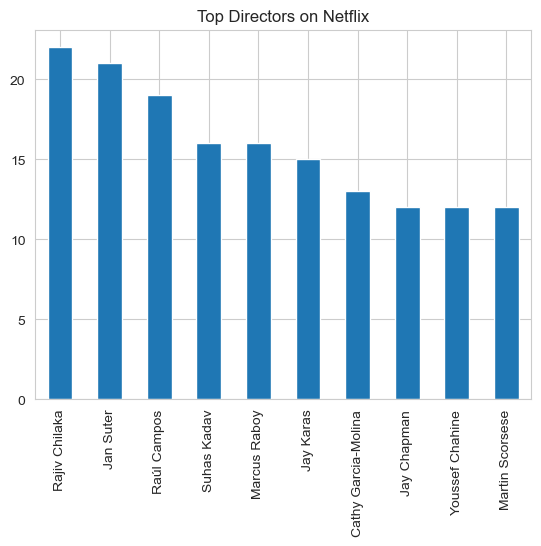

In [145]:
directors= df["director"].str.split(", ").explode()
top_directors=directors.value_counts().head(10)
top_directors.plot(kind="bar")
plt.title("Top Directors on Netflix")
plt.show()

### Insight

A small number of directors contribute multiple titles, indicating repeated collaborations or popular creators within the Netflix ecosystem.

---
---
## Final Business Insights

• Netflix has significantly expanded its content library since 2016, indicating rapid platform growth.  
• Movies dominate the catalog, but TV shows are increasing steadily, reflecting a shift toward serialized storytelling.  
• The United States remains the primary content producer, while international markets like India are growing rapidly.  
• Popular genres such as Drama and International Movies highlight Netflix's global content strategy.  
• Most content is added within a few years of release, showing a preference for recent content.  
• Increasing diversity in content suggests Netflix is targeting a broader global audience.  